In [1]:
import seaborn as sns
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import os
import pandas as pd
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
import scipy
from scipy.stats import ttest_ind

In [2]:
os.chdir('/Users/gawasi001/Documents/Paper_msc/Data_uofm/')

data = xr.open_dataset('ANHA4_mesh_zgr.nc')
dx = data.variables['e1t']
dy = data.variables['e2t']
e3t = data.variables['e3t_0']
lon = data.variables['nav_lon']
lat = data.variables['nav_lat'] 
bat = data.variables['hdept']
bat = bat[0]
e3t = e3t[0]

mask_data = xr.open_dataset('ANHA4_mask.nc')
mask = mask_data.variables['tmask']
mask = mask[0][0]

In [3]:
os.chdir('/Users/gawasi001/Documents/Paper_msc/Data_uofm/Figure4&SI5_Tracers/trc01')

vs = np.load('ANHA4-EJM010-S_2017_TRC01.npz')
vs = vs['TRC01']

vd = np.load('ANHA4-EJM012-S_2017_TRC01.npz')
vd = vd['TRC01']

In [4]:
vs_weighted = vs * e3t.values[None, :, None, None]
vd_weighted = vd * e3t.values[None, :, None, None]

In [5]:
integ0_55vs = np.nansum(vs_weighted[:, 0:18], axis = 1)
integ55_500vs = np.nansum(vs_weighted[:, 18:32], axis = 1)
integbellow500vs = np.nansum(vs_weighted[:, 32::], axis = 1)

integ0_55vd = np.nansum(vd_weighted[:, 0:18], axis = 1)
integ55_500vd = np.nansum(vd_weighted[:, 18:32], axis = 1)
integbellow500vd = np.nansum(vd_weighted[:, 32::], axis = 1)



In [6]:
dif_0_55 = integ0_55vd[72] - integ0_55vs[72]
dif_55_500 = integ55_500vd[72] - integ55_500vs[72]
dif_bellow500 =  integbellow500vd[72] - integbellow500vs[72]

In [7]:
stat_upper, p_val_upper = ttest_ind(integ0_55vd, integ0_55vs, axis=0, nan_policy='omit')
stat_ss, p_val_ss = ttest_ind(integ55_500vd, integ55_500vs, axis=0, nan_policy='omit')
stat_deeper, p_val_deeper = ttest_ind(integbellow500vd, integbellow500vs, axis=0, nan_policy='omit')

In [8]:
dif_0_55[np.where(p_val_upper > 0.05)] = np.nan

dif_55_500[np.where(p_val_ss > 0.05)] = np.nan

dif_bellow500[np.where(p_val_deeper > 0.05)] = np.nan

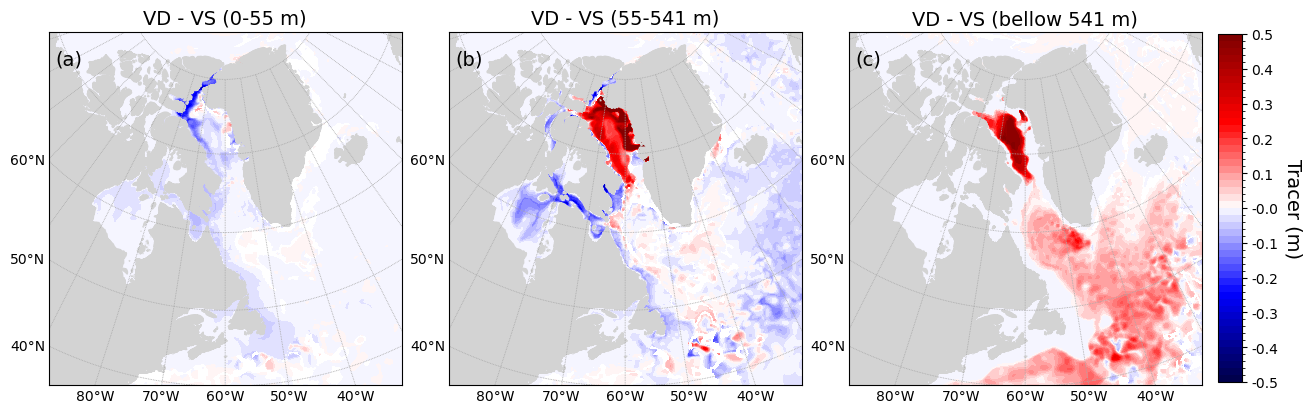

In [9]:
vmin = -0.5
vmax = 0.5
levels = 50
lv = (vmax - vmin) / levels
levels = list(np.arange(vmin, vmax + lv, lv))
cmap = plt.get_cmap('seismic')

dif_0_55_clip = np.clip(dif_0_55, vmin, vmax)
dif_55_500_clip = np.clip(dif_55_500, vmin, vmax)
dif_bellow500_clip = np.clip(dif_bellow500, vmin, vmax)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4), constrained_layout=True)

titles = ['VD - VS (0-55 m)', 'VD - VS (55-541 m)', 'VD - VS (bellow 541 m)']
datasets = [dif_0_55_clip, dif_55_500_clip, dif_bellow500_clip]
pvals = [p_val_upper, p_val_ss, p_val_deeper]

for ax, data, data2, title in zip(axes, datasets, pvals, titles):
    m = Basemap(projection='aea', resolution='f', width=5E6, height=5E6, lat_0=63, lon_0=-60, ax=ax)
    cs = m.contourf(lon, lat, data, latlon=True, levels=levels, vmin=vmin, vmax=vmax, cmap=cmap)

    m.drawcoastlines(color='lightgray')
    m.fillcontinents(color='lightgray', lake_color='lightgray')
    m.drawmeridians(np.arange(0, 360, 10), labels=[0,0,0,1], linewidth=0.6, color='darkgray', fontsize=10)
    m.drawparallels(np.arange(-90, 90, 10), labels=[1,0,0,0], linewidth=0.6, color='darkgray', fontsize=10)
    ax.set_title(title, fontsize=14)


cax = fig.add_axes([1.01, 0.060, 0.020, 0.87])
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label('Tracer (m)', rotation=270, labelpad=17, fontsize=14)
cb.ax.ticklabel_format(style='plain', axis='both')

ticks = np.arange(vmin, vmax + 0.01, 0.1)
cb.set_ticks(ticks)
cb.set_ticklabels([f"{t:.1f}" for t in ticks])

labels = ['a', 'b', 'c']

for i, ax in enumerate(axes):
    ax.text(0.02, 0.95, f'({labels[i]})', transform=ax.transAxes,
            fontsize=14, va='top', ha='left')

figure_title = 'TracerDifferences(0-50)(50-500)(bellow500)'
os.chdir('/Users/gawasi001/Documents/Paper_msc/Data_uofm/Figure4&SI5_Tracers/')
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
final_vs = vs[72]
final_vd = vd[72]

print(np.shape(final_vs))

dif_final = final_vd - final_vs

(50, 800, 544)


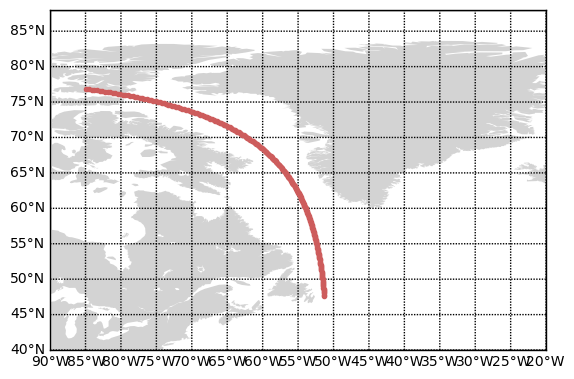

In [33]:
os.chdir('/Users/gawasi001/Documents/Paper_msc/Data_uofm/')

data_mask = xr.open_dataset('ANHA4_mask.nc')

mask = data_mask.variables['tmask']
mask = mask[0][0]

data_grid = xr.open_dataset('/Users/gawasi001/Documents/Paper_msc/Data_uofm/ANHA4-EJM010_y2017m12d31_gridT.nc')

lat = data_grid.variables['nav_lat_grid_T']
lon = data_grid.variables['nav_lon_grid_T']
lon = np.asarray(lon)
lat = np.asarray(lat)
depth = data_grid.variables['deptht']

depths = np.arange(0, 43)
lats = np.arange(300, 550)
lons = 190

s1 = lats # or slat_ds
s2 = lons # or slon_ds

sec = np.copy(mask)
sec[s1, s2] = 5
sec[np.where(sec != 5)] = np.nan

m = Basemap(projection='cyl', llcrnrlon=-90, llcrnrlat=40, urcrnrlon=-20, urcrnrlat=88, resolution = 'l')

m.drawmeridians(np.arange(0,360,5), labels=[0, 0, 0, 1])
m.drawparallels(np.arange(-90,90,5), labels=[1, 0, 0, 0])
m.drawmapboundary()
m.fillcontinents(color='lightgray')

lons = lon[s1,s2]
lats = lat[s1,s2]

x, y = m(lons,lats)

m.plot(x, y, marker=".",color='indianred')

plt.show()



In [34]:
sec_lat = lat[ s1, s2]
sec_lon = lon[ s1, s2]
sec_depth = depth[0: len(depth)-7]

tmask = data_mask.variables['tmask']
tmask = tmask[0, 0:len(sec_depth),s1, s2]

mask = np.zeros(np.shape(tmask))

for i in range(0, len(tmask)):
    for j in range(0, len(tmask[0])):
        if tmask[i][j] == np.float32(1):
            mask[i][j] = np.nan

In [35]:
xp, yp = np.meshgrid(sec_lon, sec_depth)

In [43]:
sec_dif_final = dif_final[:43, s1, s2]

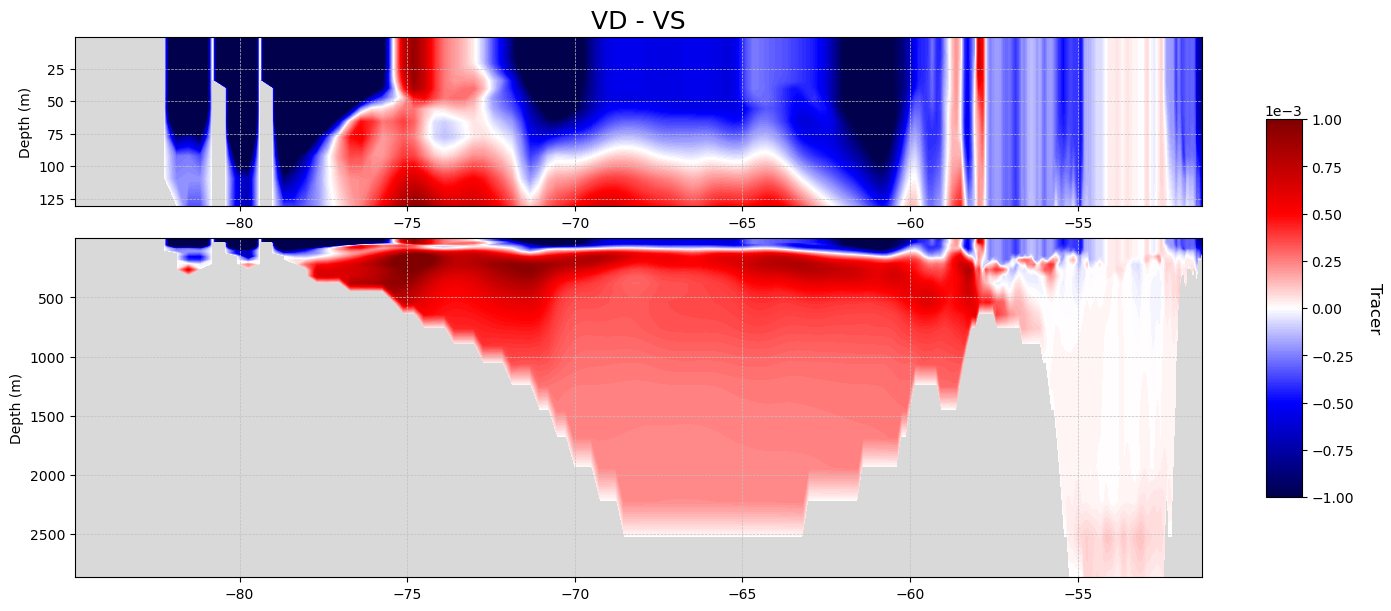

In [45]:
dpt = 24
vmin = -0.001
vmax = 0.001
cmap = 'seismic'
levels = 500

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), constrained_layout=True, 
                       gridspec_kw={'height_ratios': [1, 2]})

ax[0].contourf(xp[:dpt], yp[:dpt], sec_dif_final[:dpt, :], levels=levels, vmin=vmin, vmax=vmax, cmap=cmap, zorder=1)
ax[0].contourf(xp[:dpt], yp[:dpt], mask[:dpt, :], cmap='Greys')
ax[0].set_ylim(max(sec_depth[:dpt]), min(sec_depth[:dpt]))
ax[0].grid(color='silver', linestyle='--', linewidth=0.5)
ax[0].set_title("VD - VS", fontsize=18)
ax[0].set_ylabel("Depth (m)")

ax[1].contourf(xp, yp, sec_dif_final, levels=levels, vmin=vmin, vmax=vmax, cmap=cmap, zorder=1)
ax[1].contourf(xp, yp, mask, cmap='Greys')
ax[1].set_ylim(max(sec_depth), min(sec_depth))
ax[1].grid(color='silver', linestyle='--', linewidth=0.5)
ax[1].set_ylabel("Depth (m)")

cax = fig.add_axes([1.05, 0.18, 0.030, 0.63])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb1 = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation='vertical')
cb1.ax.set_ylabel('Tracer', rotation=270, labelpad=20, fontsize=12)
cb1.ax.ticklabel_format(style='sci', scilimits=(-1, 4), axis='both')

figure_title = 'LargeTransectTracers'
os.chdir('/Users/gawasi001/Documents/Paper_msc/Data_uofm/Figure4&SI5_Tracers/')
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()
